In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from uncertainties import ufloat, unumpy
from scipy.signal import find_peaks
from scipy.constants import h, c, e

from basics import load_images, convert_into_array, sort_data, plot_image_profiles
from calibration import k_lambda_fit, fit_B_with_b_k0_uncertainties, lambda_cal, fit_gaussian_intensity_profiles
from fits import single_gaussian_fit, polynomial_fit, polynomial, polyfit_peak

# some constants
p_central = 720
s_p = ufloat(3.45*10**3,0) # pixel size in nm
plt.style.use('default')

/home/lorenz/Dokumente/Datenanalyse/.venv/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


# Calibration

[ WARN:0@0.124] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32768 (0x8000) encountered
[ WARN:0@0.124] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32769 (0x8001) encountered
[ WARN:0@0.124] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32770 (0x8002) encountered
[ WARN:0@0.124] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32771 (0x8003) encountered
[ WARN:0@0.124] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32772 (0x8004) encountered
[ WARN:0@0.124] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32773 (0x8005) encountered
[ WARN:0@0.124] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32774 (0x8006) encountered
[ WARN:0@0.124] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32775 (0x8007) encountered
[ WARN:0

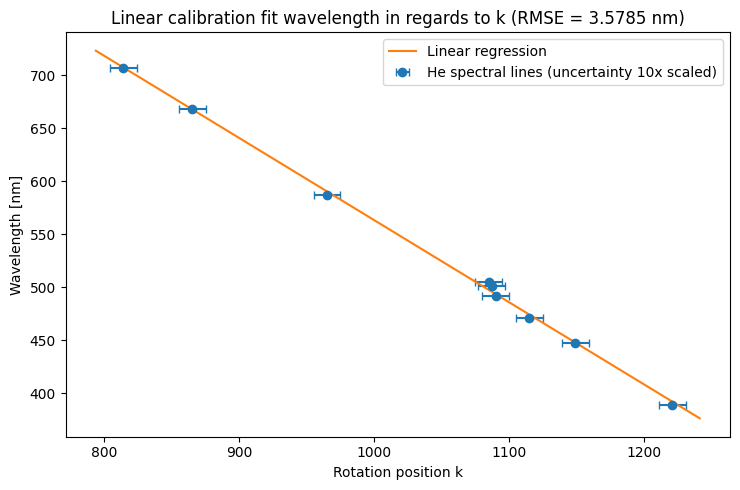

-0.775+/-0.011 1727+/-10


In [2]:
# relation k to lamda
# set folder path
path_k_lamda_Notizen = "/home/lorenz/Dokumente/Datenanalyse/P2/Spectroscopy_3/Notizen"
path_k_lamda_Bilder = "/home/lorenz/Dokumente/Datenanalyse/P2/Spectroscopy_3/Bilder/k_lamda"

# load images, generate 1-D spectra and sort them in a dict
images_k_lamda = load_images(path_k_lamda_Bilder)
images_one_line_k_lambda, raw_one_line_k_lamda = convert_into_array(images_k_lamda)
img_dic_k_lambda = sort_data(path_k_lamda_Bilder, path_k_lamda_Notizen, images_one_line_k_lambda, "k-values")

# define Helium lines
#He_spectrum = np.array([388.8,447.1,471.3,492.1,501.5,504.7,587.5,667.8, 706.5])
He_spectrum = np.array([706.5, 667.8,587.5,504.7,501.5,492.1,471.3,447.1,388.8])
k_measured_lamda = np.array([img_dic_k_lambda[name]['k_value'] for name in img_dic_k_lambda])

# sanity check
if len(He_spectrum) != len(k_measured_lamda):
    raise Exception("Zu viele oder zu wenig Linien detektiert :/")

# uncertainties
sigma_k_lambda = np.ones_like(k_measured_lamda)
sigma_lambda = None

# linear fit for relation, k and lamda
b, k0 = k_lambda_fit(He_spectrum, k_measured_lamda, sigma_k_lambda)
print(b,k0)

[ WARN:0@1.311] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32768 (0x8000) encountered
[ WARN:0@1.311] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32769 (0x8001) encountered
[ WARN:0@1.311] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32770 (0x8002) encountered
[ WARN:0@1.311] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32771 (0x8003) encountered
[ WARN:0@1.311] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32772 (0x8004) encountered
[ WARN:0@1.311] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32773 (0x8005) encountered
[ WARN:0@1.311] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32774 (0x8006) encountered
[ WARN:0@1.311] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32775 (0x8007) encountered
[ WARN:0

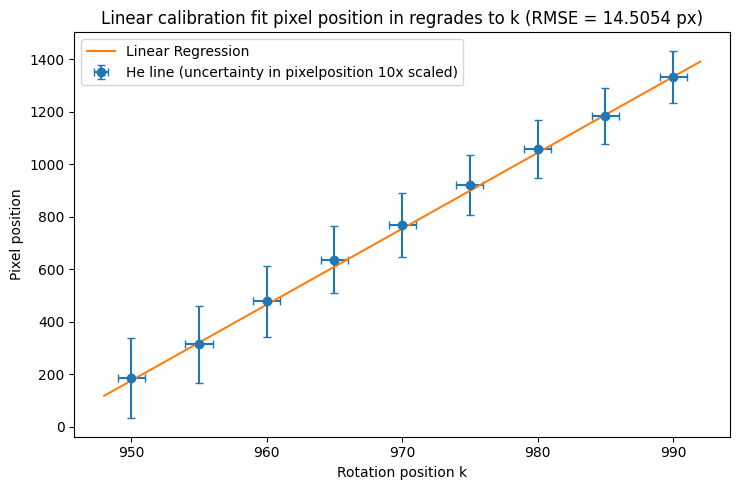

-28.9+/-0.4


In [3]:
# relation k to p
# set folder path
path_p_k_Notizen = "/home/lorenz/Dokumente/Datenanalyse/P2/Spectroscopy_3/Notizen"
path_p_k_Bilder = "/home/lorenz/Dokumente/Datenanalyse/P2/Spectroscopy_3/Bilder/p_cal"

# load images, generate 1-D spectra and sort them in a dict
images_p_k = load_images(path_p_k_Bilder)
images_one_line_p_k, raw_one_line_p_k = convert_into_array(images_p_k )
img_dic_p_k = sort_data(path_p_k_Bilder, path_p_k_Notizen, images_one_line_p_k, "p_cal")

# fit gaussian curve for every calibration image
fit_results_p_k = fit_gaussian_intensity_profiles(img_dic_p_k)
lambda0 = 587.5 # adjust

# linear fit for relation, k and px
B = fit_B_with_b_k0_uncertainties(img_dic_p_k, fit_results_p_k,b,k0,lambda0,p_central)

print(B)

In [4]:
# FWHM
x = np.linspace(0, 1440, 1440)
selected_image = "p_cal_2026-04-23T13-37-56.942" # adjust
y = img_dic_p_k[selected_image]["pixel_values"]
A1 = fit_results_p_k[selected_image]["A"]
mu1 = fit_results_p_k[selected_image]["mu"]
sigma1 = fit_results_p_k[selected_image]["sigma"]
C = fit_results_p_k[selected_image]["C"]


fwhm_px = ufloat(2 * np.sqrt(2 * np.log(2)) * sigma1, sigma1)
fwhm_lambda = fwhm_px*s_p
print(f"FWHM (px): {fwhm_px}")
print(f"FWHM (nm): {fwhm_lambda}")

FWHM (px): 28+/-12
FWHM (nm): (1.0+/-0.4)e+05


# Free Spectral Range

In [5]:
# define folder paths
path_frs_Notizen = "/home/lorenz/Dokumente/Datenanalyse/P2/Spectroscopy_3/Notizen/"
path_frs_Bilder = "/home/lorenz/Dokumente/Datenanalyse/P2/Spectroscopy_3/Bilder/frs"

# load images, generate 1-D spectra and sort them in a dict
images_frs = load_images(path_frs_Bilder)
images_one_line_frs, raw_one_line_frs = convert_into_array(images_frs)
img_dic_frs = sort_data(path_frs_Bilder, path_frs_Notizen, images_one_line_frs, "frs")

# calculate peaks and free spectral range
prt = False
for name in img_dic_frs:
    # extract spectra
    spectra = img_dic_frs[name]["pixel_values"]

    # find peaks
    peak_indices, properties = find_peaks(spectra, prominence=0.02)
    peak_indices = peak_indices[1:-1]

    if prt == True:
        plt.figure(figsize=(8, 5))
        plt.title(name)
        plt.style.use('default')
        plt.plot(np.arange(0, len(spectra)), spectra, label="spectra")
        for index in range(len(peak_indices)):
            plt.axvline(x=peak_indices[index], color='orange')
        plt.xlabel("Pixel number")
        plt.ylabel("Intensity (normalized)")
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f'find_peaks_{name}.png', dpi=600)
        plt.show()

    # create uncertainty array for peaks
    peak_u = unumpy.uarray(peak_indices, np.zeros_like(peak_indices))

    # fit 2 degree polynomial through each peak to calculate uncertainty
    for i in range(len(peak_indices)):
        # extract peak indices and define fit range
        current_peak = peak_indices[i]
        if i < len(peak_indices) - 1:
            next_peak = peak_indices[i+1]
            middle_index_next = current_peak + np.abs(current_peak-next_peak)//8 # estimated index between current peak and the next one
        else:
            middle_index_next = current_peak+25
        if i == 0:
            middle_index_last = current_peak-25
        else:
            last_peak = peak_indices[i-1]
            middle_index_last = current_peak - np.abs(current_peak-last_peak)//8 # estimated index between current peak and the last one

        #if i < len(peak_indices) - 1 and i != 0:
        x = np.arange(middle_index_last, middle_index_next)

        # create uncertainty value
        peak_u[i] = polyfit_peak(x, spectra[middle_index_last:middle_index_next])

    # extract k and convert pixel values to wavelength
    k_frs = ufloat(img_dic_frs[name]["k_value"], 1)
    peak_lambda = lambda_cal(b, k0, p_central, B, k_frs, peak_u)
    img_dic_frs[name]["peak_pixels"] = peak_u
    img_dic_frs[name]["peak_lambdas"] = peak_lambda

    # calculate free spectral range (possible problems when combining numpy and uncertainties package)
    diffs = [peak_lambda[i+1] - peak_lambda[i] for i in range(len(peak_lambda)-1)]
    fsr = sum(diffs) / len(diffs)

    # store results in dictionary
    img_dic_frs[name]["fsr"] = fsr
    img_dic_frs[name]["peaks"] = peak_lambda

# function which returns de distance between the two mirrors
def mirror_distance(wavelength, fsr):
    return ((wavelength**2 / fsr) - wavelength) * 0.5

# output free spectral range and the distance between the mirrors for every image
for name in img_dic_frs:
    fsr = img_dic_frs[name]['fsr']
    peaks = img_dic_frs[name]['peaks']
    l_arr = mirror_distance(img_dic_frs[name]['peaks'], img_dic_frs[name]['fsr']) * 1e-3 # micrometer
    l_mean = sum(l_arr) / len(l_arr)

    print(f"{name}: FSR = $({fsr:.1uL})\\,\\mathrm{{nm}}$, l = $({l_mean:.1uL})\\,\\mathrm{{µm}}$")

# LaTeX output written by ChatGPT
# LaTeX table with every detected peak
def latex_peak_table(img_dic_frs, caption="Detected transmission peaks", label="tab:frs_peaks"):
    lines = []
    lines.append(r"\begin{longtable}{l c c c}")
    lines.append(r"\caption{" + caption + r"}\label{" + label + r"}\\")
    lines.append(r"\toprule")
    lines.append(r"Measurement & Peak no. & Pixel position & Wavelength / $\mathrm{nm}$ \\")
    lines.append(r"\midrule")
    lines.append(r"\endfirsthead")
    lines.append(r"\toprule")
    lines.append(r"Measurement & Peak no. & Pixel position & Wavelength / $\mathrm{nm}$ \\")
    lines.append(r"\midrule")
    lines.append(r"\endhead")

    for name in img_dic_frs:
        peak_pixels = img_dic_frs[name]["peak_pixels"]
        peak_lambdas = img_dic_frs[name]["peak_lambdas"]

        for i, (px, lam) in enumerate(zip(peak_pixels, peak_lambdas), start=1):
            if i == 1:
                meas = name.replace("_", r"\_")
            else:
                meas = ""

            lines.append(
                rf"{meas} & {i} & ${px:.1uL}$ & ${lam:.1uL}$ \\"
            )

        lines.append(r"\midrule")

    lines[-1] = r"\bottomrule"
    lines.append(r"\end{longtable}")

    return "\n".join(lines)


print(latex_peak_table(img_dic_frs))

frs_2026-04-23T14-23-06.671_2: FSR = $(2.90 \pm 0.06)\,\mathrm{nm}$, l = $(64 \pm 2)\,\mathrm{µm}$
frs_2026-04-23T14-57-37.612: FSR = $(1.7 \pm 0.1)\,\mathrm{nm}$, l = $(\left(1.1 \pm 0.1\right) \times 10^{2})\,\mathrm{µm}$
frs_2026-04-23T14-59-16.039: FSR = $(5.4 \pm 0.2)\,\mathrm{nm}$, l = $(34 \pm 2)\,\mathrm{µm}$
frs_2026-04-23T14-59-46.155: FSR = $(8 \pm 2)\,\mathrm{nm}$, l = $(22 \pm 4)\,\mathrm{µm}$
\begin{longtable}{l c c c}
\caption{Detected transmission peaks}\label{tab:frs_peaks}\\
\toprule
Measurement & Peak no. & Pixel position & Wavelength / $\mathrm{nm}$ \\
\midrule
\endfirsthead
\toprule
Measurement & Peak no. & Pixel position & Wavelength / $\mathrm{nm}$ \\
\midrule
\endhead
frs\_2026-04-23T14-23-06.671\_2 & 1 & $126 \pm 4$ & $\left(6.0 \pm 0.1\right) \times 10^{2}$ \\
 & 2 & $228 \pm 2$ & $\left(6.0 \pm 0.1\right) \times 10^{2}$ \\
 & 3 & $\left(3.3 \pm 0.2\right) \times 10^{2}$ & $\left(6.0 \pm 0.1\right) \times 10^{2}$ \\
 & 4 & $\left(4.4 \pm 0.3\right) \times 10^{

[ WARN:0@2.651] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32768 (0x8000) encountered
[ WARN:0@2.651] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32769 (0x8001) encountered
[ WARN:0@2.651] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32770 (0x8002) encountered
[ WARN:0@2.651] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32771 (0x8003) encountered
[ WARN:0@2.651] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32772 (0x8004) encountered
[ WARN:0@2.651] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32773 (0x8005) encountered
[ WARN:0@2.651] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32774 (0x8006) encountered
[ WARN:0@2.651] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32775 (0x8007) encountered
[ WARN:0

# Cavity dispersion

[ WARN:0@2.826] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32768 (0x8000) encountered
[ WARN:0@2.826] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32769 (0x8001) encountered
[ WARN:0@2.826] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32770 (0x8002) encountered
[ WARN:0@2.826] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32771 (0x8003) encountered
[ WARN:0@2.826] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32772 (0x8004) encountered
[ WARN:0@2.826] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32773 (0x8005) encountered
[ WARN:0@2.826] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32774 (0x8006) encountered
[ WARN:0@2.826] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32775 (0x8007) encountered
[ WARN:0

0.0+/-0 0.0002+/-0 0.00035+/-0
0.0+/-0 0.0002+/-0 0.00035+/-0


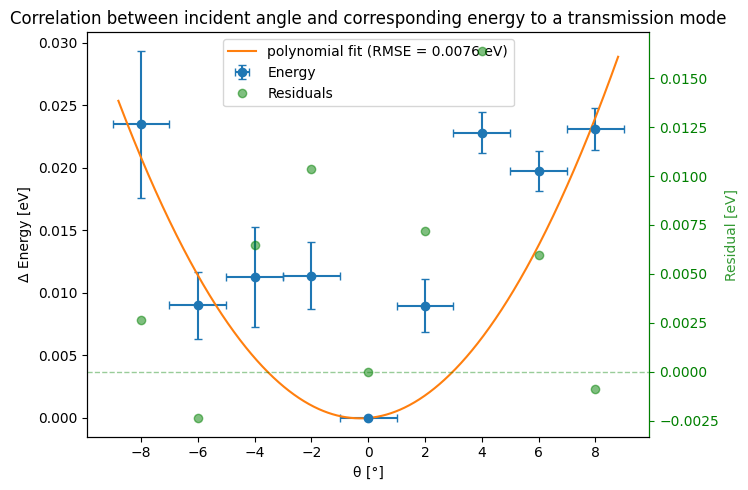

In [6]:
# define folder paths
path_disp_Notizen = "/home/lorenz/Dokumente/Datenanalyse/P2/Spectroscopy_3/Notizen/"
path_disp_Bilder = "/home/lorenz/Dokumente/Datenanalyse/P2/Spectroscopy_3/Bilder/dispersion"

# load images, generate 1-D spectra and sort them in a dict
images_disp = load_images(path_disp_Bilder)
images_one_line_disp, raw_one_line_disp = convert_into_array(images_disp)
img_dic_disp = sort_data(path_disp_Bilder, path_disp_Notizen, images_one_line_disp, "dispersion")

# load theta values
theta_measured = np.loadtxt(os.path.join(path_disp_Notizen, "theta.txt"), delimiter=',')[:, 1]

# get image names in the same order as in sort_data
filenames = sorted([f for f in os.listdir(path_disp_Bilder)])
names = [os.path.splitext(f)[0] for f in filenames]

# attach theta to dictionary
for name, theta in zip(names, theta_measured):
    img_dic_disp[name]["theta"] = theta

# sort by ascending theta
sorted_names = sorted(img_dic_disp, key=lambda name: img_dic_disp[name]["theta"])

# choose one peak in first spectrum
first_name = sorted_names[0]
first_spectrum = img_dic_disp[first_name]["pixel_values"]

# choose trackable peak by looking which is the nearest to the center of the image
peak_indices, properties = find_peaks(first_spectrum, prominence=0.03)
tracked_peak = peak_indices[np.argmin(np.abs(peak_indices - p_central))]

#peak_px = polyfit_peak(x, spectra[middle_index_last:middle_index_next])

# track peak through all spectra
for name in sorted_names:
    # extract spectrum and metadata
    spectra = img_dic_disp[name]["pixel_values"]
    theta = img_dic_disp[name]["theta"]
    k_val = img_dic_disp[name]["k_value"]

    # find peaks
    peak_indices, properties = find_peaks(spectra, prominence=0.01)

    # choose peak closest to previous one
    i_peak = np.argmin(np.abs(peak_indices - tracked_peak))
    current_peak = peak_indices[i_peak]

    if prt == True:
        # plot found peaks
        plt.figure(figsize=(8, 5))
        plt.title(f"{theta}")
        plt.style.use('default')
        plt.plot(np.arange(0, len(spectra)), spectra, label="spectra")
        for index in range(len(peak_indices)):
            plt.axvline(x=peak_indices[index], color='orange')
        plt.axvline(x=current_peak, color='red')
        plt.xlabel("Pixel number")
        plt.ylabel("Intensity (normalized)")
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"fit_{name}.png", dpi=600)
        plt.show()

    # define fit range
    if i_peak<len(peak_indices)-1:
        next_peak = peak_indices[i_peak+1]
        middle_index_next = current_peak+abs(current_peak-next_peak) // 8
    else:
        middle_index_next = current_peak+25

    if i_peak==0:
        middle_index_last = current_peak-25
    else:
        last_peak = peak_indices[i_peak-1]
        middle_index_last = current_peak-abs(current_peak-last_peak) // 8

    x = np.arange(middle_index_last, middle_index_next)

    # create uncertainty value
    peak_px = polyfit_peak(x, spectra[middle_index_last:middle_index_next])

    # convert to wavelength
    peak_lambda = lambda_cal(b, k0, p_central, B, k_val, peak_px)

    # store result
    img_dic_disp[name]["tracked_peak_lambda"] = peak_lambda

    # update tracked peak position
    tracked_peak = peak_px

# calculate energies from wavelengths
for name in img_dic_disp:
    img_dic_disp[name]["energy"] = h * c / (img_dic_disp[name]["tracked_peak_lambda"]*10**(-9)) / e # eV

# extract energies and angles in arrays for plotting
energy_0 = next(img_dic_disp[name]["energy"] for name in img_dic_disp if img_dic_disp[name]["theta"] == 0) # extract energy at θ=0
energies_delta_u = abs(np.array([img_dic_disp[name]["energy"] for name in img_dic_disp]) - energy_0)

energies_delta = unumpy.nominal_values(energies_delta_u)
energies_delta_sigma = unumpy.std_devs(energies_delta_u)

thetas = np.array([img_dic_disp[name]["theta"] for name in img_dic_disp])

# x- and y-axis for the fit
theta_min, theta_max = np.min(thetas), np.max(thetas)
theta_pad = 0.05 * (theta_max - theta_min)
theta_fit = np.linspace(theta_min - theta_pad, theta_max + theta_pad, 1000)

a, c, d = polynomial_fit(thetas, energies_delta, 1, energies_delta_sigma, [0, 2e-4, 3.5e-4])
print(a,c,d)
energies_fit = polynomial([a.n, c.n, d.n], theta_fit)
in_guess = polynomial([0, 2e-4, 3.5e-4], theta_fit)

# RSME
energies_fit_data = polynomial([a.n, c.n, d.n], thetas)
residuals = energies_delta - energies_fit_data
rmse = np.sqrt(np.mean(residuals ** 2))

# plot coded by ChatGPT
plt.style.use('default')

fig, ax1 = plt.subplots(figsize=(7.5, 5))

# Primary axis: energy + fit
energy_plot = ax1.errorbar(
    thetas,
    energies_delta,
    xerr=1,
    yerr=energies_delta_sigma,
    fmt='o',
    capsize=3,
    label='Energy'
)

fit_plot, = ax1.plot(
    theta_fit,
    energies_fit,
    '-',
    label=rf"polynomial fit (RMSE = {rmse:.4f} eV)"
)

ax1.set_xlabel('θ [°]')
ax1.set_ylabel('Δ Energy [eV]')

# Secondary axis: residuals
ax2 = ax1.twinx()

residual_plot, = ax2.plot(
    thetas,
    residuals,
    'o',
    label='Residuals', color='green', alpha=0.5
)

ax2.axhline(0, linestyle='--', linewidth=1, color='green', alpha=0.4)
ax2.set_ylabel('Residual [eV]', color='green', alpha=0.8)
ax2.tick_params(axis='y', colors='green')
ax2.spines['right'].set_color('green')

plt.title(
    'Correlation between incident angle and corresponding energy to a transmission mode'
)

# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='best'
)

plt.tight_layout()
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.savefig('cavity_dispersion.png', dpi=600)
plt.show()

# Transmission

[ WARN:0@4.186] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32768 (0x8000) encountered
[ WARN:0@4.186] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32769 (0x8001) encountered
[ WARN:0@4.186] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32770 (0x8002) encountered
[ WARN:0@4.186] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32771 (0x8003) encountered
[ WARN:0@4.186] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32772 (0x8004) encountered
[ WARN:0@4.186] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32773 (0x8005) encountered
[ WARN:0@4.186] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32774 (0x8006) encountered
[ WARN:0@4.186] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32775 (0x8007) encountered
[ WARN:0

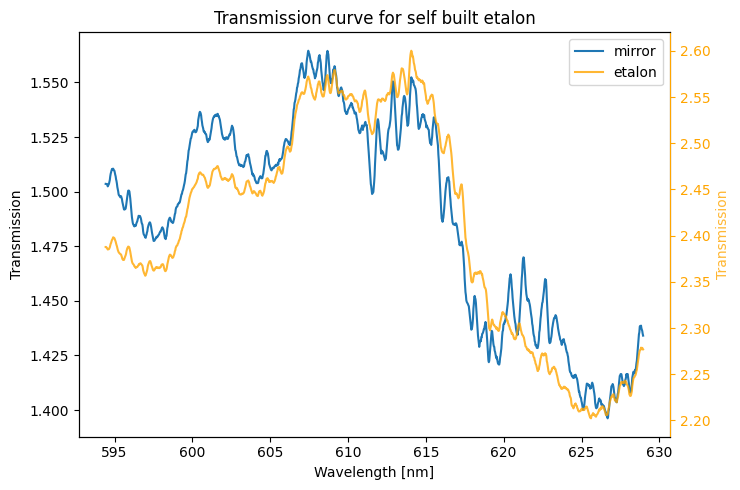

In [7]:
# define folder paths
path_diy_Notizen = "/home/lorenz/Dokumente/Datenanalyse/P2/Spectroscopy_3/Notizen/"
path_diy_Bilder = "/home/lorenz/Dokumente/Datenanalyse/P2/Spectroscopy_3/Bilder/diy"

# load images, generate 1-D spectra and sort them in a dict
images_diy = load_images(path_diy_Bilder)
images_one_line_diy, raw_one_line_diy = convert_into_array(images_diy, False)
img_dic_diy = sort_data(path_diy_Bilder, path_diy_Notizen, images_one_line_diy, "diy")

# convert pixel values to wavelength
for name in img_dic_diy:
    k_val = img_dic_diy[name]["k_value"]
    lambda_values = np.array([lambda_cal(b, k0, p_central, B, k_val, px).n for px in np.arange(0, 1440)])
    img_dic_diy[name]["lambda"] = lambda_values

# calculate transmission curve for one mirror
I = img_dic_diy["diy_2026-04-23T16-00-36.355"]["pixel_values"][:-150]
I0 = img_dic_diy["diy_2026-04-23T15-58-30.227"]["pixel_values"][:-150]
transmission_1 = np.divide(I, I0, out=np.zeros_like(I), where=I0 != 0 )

# calculate transmission curve for the etalon
I = img_dic_diy["diy_2026-04-23T16-05-37.199"]["pixel_values"][:-150]
I0 = img_dic_diy["diy_2026-04-23T15-58-30.227"]["pixel_values"][:-150]
transmission_2 = np.divide(I, I0, out=np.zeros_like(I), where=I0 != 0 )

# plot transmission curve
plt.style.use('default')
fig, ax1 = plt.subplots(figsize=(7.5, 5))
plt.title("Transmission curve for self built etalon")

# Primary axis: energy + fit
mirror_plot = ax1.plot(img_dic_diy["diy_2026-04-23T15-58-30.227"]["lambda"][:-150], transmission_1, label='mirror')
ax1.set_xlabel("Wavelength [nm]")
ax1.set_ylabel("Transmission")

# Secondary axis: residuals
ax2 = ax1.twinx()
etalon_plot = ax2.plot(img_dic_diy["diy_2026-04-23T15-58-30.227"]["lambda"][:-150], transmission_2, label='etalon', color='orange', alpha=0.8)

ax2.set_ylabel('Transmission', color='orange', alpha=0.8)
ax2.tick_params(axis='y', colors='orange')
ax2.spines['right'].set_color('orange')

# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1 + handles2, labels1 + labels2, loc='best')
plt.tight_layout()
plt.savefig('Transmission_curve_etalon.png', dpi=600)
plt.show()